Install Libraries

In [3]:
#%pip install meteostat -U
#%pip install geopy
#%pip install python-docx pyautogui
#%pip install openpyxl
#%pip install dfply
#%pip install -U scikit-learn
#%pip install mlxtend

Invoque Libraries

In [ ]:
from datetime import datetime as dt
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
from typing import Tuple, Optional, Dict
from dfply import *
from meteostat import Point
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import BayesianGaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from scipy.stats import norm
import meteostat as ms
import pandas as pd
import numpy as np
import math, os, uuid, sys, requests, re, time, statistics
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd

Create functions for Extact coordinates from intersections

In [3]:
def get_intersection_coordinates(address_1: str,address_2: str,detail_context: str,user_agent_name: str = "gabofreq") -> Optional[Dict]:
    municipality, city, postal_code = None, None, None
    final_longitud, final_latitude = float('nan'), float('nan')
    cleaned_1 = re.sub(r'\s*[&/@]\s*', ' and ', address_1, flags=re.IGNORECASE).strip()
    cleaned_2 = re.sub(r'\s*[&/@]\s*', ' and ', address_2, flags=re.IGNORECASE).strip()
    geolocator = Nominatim(user_agent="gabofreq")
    longitude_list = []
    latitude_list = []

    for i, query in enumerate([f"{cleaned_1}, {detail_context}", f"{cleaned_2}, {detail_context}"]):
        try:
            location = geolocator.geocode(query, timeout=5) 
            
            if location:
                # Store the coordinates only if found
                longitude_list.append(location.longitude)
                latitude_list.append(location.latitude)

        except (GeocoderTimedOut, GeocoderServiceError) as e:
            # print(f"Error geocoding {query}: {e}") # Suppress for clean running
            pass # Keep lists empty or incomplete on error

# Calculate the Midpoint and Extract Common Address Info ---

    if len(longitude_list) == 2:
        # Midpoint Calculation
        final_longitud = statistics.mean(longitude_list)
        final_latitude = statistics.mean(latitude_list)
        return final_latitude, final_longitud
    else:
        # If one or both weren't found, return the initial None/nan values
        # The float('nan') values are essential for Pandas to recognize the column as numeric.
        return float('nan'), float('nan')

Example

In [3]:
address_1 = "Front St E"
address_2 = "Church St"
Detail = "Toronto, Ontario, Canada"
get_intersection_coordinates(address_1,address_2,Detail) 

(43.6550903, -79.3772659)

Open Excel with the Intersections

In [6]:
file_name =  "311_database_2026.xlsx"
data = pd.read_excel(file_name, sheet_name = "COORDINATES_2026")
df = pd.DataFrame(data)
#df = df.head(100)
df.describe()

,LATITUDE,LONGITUDE
count,5326.000000,5326.000000
mean,43.700897,-79.396251
std,0.049335,0.098755
min,43.569624,-79.652423
25%,43.663824,-79.464422
50%,43.689282,-79.402929
75%,43.733775,-79.328986
max,43.849835,-79.123176


Run the function to get the Coordinates

In [ ]:
df[['LATITUDE','LONGITUDE']] = df.apply(lambda row: get_intersection_coordinates(address_1=row['INTERSECTION_1'],address_2=row['INTERSECTION_2'],detail_context="Ontario, Canada"),axis=1,result_type='expand') 
print("DataFrame with Geocoded Intersection Midpoints:")
print(df)
# Save the DataFrame to a new Excel file
#df.to_excel('NEW_COORDINATES.xlsx', index=False, sheet_name= 'DATA') 

Get the Municipality of the Coordinates

In [5]:
# Initialize the geolocator with your user agent
geolocator = Nominatim(user_agent="datapixer_app")
def get_ontario_location_municipality(row):
    # Ensure these match your actual DataFrame column names
    lat = row.get('LATITUDE')
    lon = row.get('LONGITUDE')
    if pd.isna(lat) or pd.isna(lon):
        return pd.Series([None, None, None])
    try:
        # Nominatim usage policy requires a 1-second delay between requests
        time.sleep(5) 
        location = geolocator.reverse((lat, lon), exactly_one=True, timeout=10)
        
        if not location:
            return pd.Series([None])
        address = location.raw.get('address', {})
        # In Ontario, 'county' or 'district' often represents the upper-tier municipality
        municipality = (address.get('county') or 
                        address.get('district') or 
                        address.get('suburb') or 
                        address.get('municipality'))
        return pd.Series([municipality])
    except (GeocoderTimedOut, GeocoderServiceError):
        # Catching ServiceError as well in case of 403 or 500 errors
        return pd.Series(["Timeout/Error"])

Run the function that create the Municipality of the coordinates in Ontario

In [6]:
df[['MUNICIPALITY']] = df.apply(get_ontario_location_municipality, axis=1)
print(df)
# Save the DataFrame to a new Excel file
#df.to_excel('NEW_MUNICIPALITY.xlsx', index=False, sheet_name= 'Data') 

                                  ADDRESS   LATITUDE  LONGITUDE MUNICIPALITY
0                  Aileen Ave & Regent St  43.683905 -79.470900         York
1               Annette St & Armadale Ave  43.658710 -79.487016         None
2                  Annette St & Mavety St  43.664021 -79.465218         None
3   Ashwood Cres & Princess Margaret Blvd  43.670324 -79.547048    Etobicoke
4                   Audrey Ave & Dodge Rd  43.689063 -79.274808  Scarborough
..                                    ...        ...        ...          ...
95            Montclair Ave & Bathurst St  43.686550 -79.419567         None
96              Mulberry Cres & Winona Dr  43.688219 -79.434907         York
97                Nancy Ave & Presley Ave  43.707152 -79.287013  Scarborough
98             Nealon Ave & Broadview Ave  43.683176 -79.357172         None
99           Nicholson Lane & Berkeley St  43.651120 -79.363722         None

[100 rows x 4 columns]


Get the City of the Coordinates

In [7]:
def get_ontario_location_city(row):
    # Ensure these match your actual DataFrame column names
    lat = row.get('LATITUDE')
    lon = row.get('LONGITUDE')
    if pd.isna(lat) or pd.isna(lon):
        return pd.Series([None, None, None])
    try:
        # Nominatim usage policy requires a 10-second delay between requests
        time.sleep(1) 
        location = geolocator.reverse((lat, lon), exactly_one=True, timeout=10)
        
        if not location:
            return pd.Series([None])
        address = location.raw.get('address', {})
        # Expanded logic for Ontario's diverse administrative labels
        city = (address.get('city') or 
                address.get('town') or 
                address.get('village'))
        return pd.Series([city])
    except (GeocoderTimedOut, GeocoderServiceError):
        # Catching ServiceError as well in case of 403 or 500 errors
        return pd.Series(["Timeout/Error"])

Run the function that create the City of the coordinates in Ontario

In [8]:
df[['CITY']] = df.apply(get_ontario_location_city, axis=1)
print(df)
# Save the DataFrame to a new Excel file
#df.to_excel('NEW_CITY.xlsx', index=False, sheet_name= 'Data') 

                                  ADDRESS   LATITUDE  LONGITUDE MUNICIPALITY  \
0                  Aileen Ave & Regent St  43.683905 -79.470900         York   
1               Annette St & Armadale Ave  43.658710 -79.487016         None   
2                  Annette St & Mavety St  43.664021 -79.465218         None   
3   Ashwood Cres & Princess Margaret Blvd  43.670324 -79.547048    Etobicoke   
4                   Audrey Ave & Dodge Rd  43.689063 -79.274808  Scarborough   
..                                    ...        ...        ...          ...   
95            Montclair Ave & Bathurst St  43.686550 -79.419567         None   
96              Mulberry Cres & Winona Dr  43.688219 -79.434907         York   
97                Nancy Ave & Presley Ave  43.707152 -79.287013  Scarborough   
98             Nealon Ave & Broadview Ave  43.683176 -79.357172         None   
99           Nicholson Lane & Berkeley St  43.651120 -79.363722         None   

       CITY  
0   Toronto  
1   Toronto

Get the Postal Code of the Coordinates

In [9]:
def get_ontario_location_postalcode(row):
    # Ensure these match your actual DataFrame column names
    lat = row.get('LATITUDE')
    lon = row.get('LONGITUDE')
    if pd.isna(lat) or pd.isna(lon):
        return pd.Series([None])
    try:
        # Nominatim usage policy requires a 1-second delay between requests
        time.sleep(1) 
        location = geolocator.reverse((lat, lon), exactly_one=True, timeout=10)
        
        if not location:
            return pd.Series([None])
        address = location.raw.get('address', {})
        postal_code = address.get('postcode')
        
        return pd.Series([postal_code])

    except (GeocoderTimedOut, GeocoderServiceError):
        # Catching ServiceError as well in case of 403 or 500 errors
        return pd.Series(["Timeout/Error"])

Run the function that create the Postal Code of the coordinates in Ontario

In [10]:
df[['POSTAL_CODE']] = df.apply(get_ontario_location_postalcode, axis=1)
print(df)
# Save the DataFrame to a new Excel file
#df.to_excel('NEW_POSTAL_CODE.xlsx', index=False,   sheet_name= 'Data') 

                                  ADDRESS   LATITUDE  LONGITUDE MUNICIPALITY  \
0                  Aileen Ave & Regent St  43.683905 -79.470900         York   
1               Annette St & Armadale Ave  43.658710 -79.487016         None   
2                  Annette St & Mavety St  43.664021 -79.465218         None   
3   Ashwood Cres & Princess Margaret Blvd  43.670324 -79.547048    Etobicoke   
4                   Audrey Ave & Dodge Rd  43.689063 -79.274808  Scarborough   
..                                    ...        ...        ...          ...   
95            Montclair Ave & Bathurst St  43.686550 -79.419567         None   
96              Mulberry Cres & Winona Dr  43.688219 -79.434907         York   
97                Nancy Ave & Presley Ave  43.707152 -79.287013  Scarborough   
98             Nealon Ave & Broadview Ave  43.683176 -79.357172         None   
99           Nicholson Lane & Berkeley St  43.651120 -79.363722         None   

       CITY POSTAL_CODE  
0   Toronto  

Create database of the meteorological stations, near to the coordinate, with state active and updated until now

In [11]:
# Get station inventory
ID = 'NZY2Y'
inventory = ms.stations.inventory(ID)
station = ms.stations.meta(ID)
print(f"Data available from {inventory.start} to {inventory.end}.")
print(f"The name of the station is: {station.name}")
print(f"Location: {station.latitude, station.longitude, station.elevation}")

Data available from 1994-11-01 to 2026-03-03.
The name of the station is: Toronto North York
Location: (43.78, -79.47, 187)


In [7]:
my_stations = [
{'ID': '71508', 'LATITUDE': 43.67,  'LONGITUDE': -79.4},      # Toronto city                          71508   43.67   -79.4     112
{'ID': '71624', 'LATITUDE': 43.68,  'LONGITUDE': -79.63},     # Toronto Pearson International Airport 71624   43.68   -79.63    173
{'ID': 'NZY2Y', 'LATITUDE': 43.78,  'LONGITUDE': -79.47},     # Toronto North York                    NZY2Y   43.78   -79.47    187
{'ID': 'SEURC', 'LATITUDE': 45.43,  'LONGITUDE': -79.49},     # Sprucedale                            SEURC   45.43   -79.49    337
{'ID': '71630', 'LATITUDE': 44.97,  'LONGITUDE': -79.3},      # Muskoka Airport                       71630	  44.97	  -79.3	    282
{'ID': '71314', 'LATITUDE': 44.48,  'LONGITUDE': -79.55},     # Barrie-Oro                            71314	  44.48	  -79.55	289
{'ID': '71296', 'LATITUDE': 44.23,  'LONGITUDE': -79.78},     # Egbert CS                             71296	  44.23	  -79.78	251
{'ID': '71436', 'LATITUDE': 44.3833,'LONGITUDE': -79.7833},   # Barrie, Ontario                       71436	  44.3833 -79.7833	295
{'ID': '71534', 'LATITUDE': 44.27,  'LONGITUDE': -79.91},     # Borden Awos                           71534	  44.27	  -79.91	222
{'ID': '71694', 'LATITUDE': 45.14,  'LONGITUDE': -79.4},      # Beatrice                              71694	  45.14	  -79.4	    297
{'ID': '71282', 'LATITUDE': 44.55,  'LONGITUDE': -79.22},     # Lagoon City                           71282	  44.55	  -79.22	221
{'ID': '8TSI8', 'LATITUDE': 44.39,  'LONGITUDE': -79.74},     # Barrie Landfill                       8TSI8	  44.39	  -79.74	305 
{'ID': 'KKCUP', 'LATITUDE': 44.26,  'LONGITUDE': -79.16},     # Udora                                 KKCUP	  44.26	  -79.16	262
{'ID': '82JYP', 'LATITUDE': 44.1,   'LONGITUDE': -79.16},     # UxbrIDge West                         82JYP	  44.1	  -79.16	325
{'ID': '3EADS', 'LATITUDE': 44.63,  'LONGITUDE': -79.54},     # Coldwater Warminster                  3EADS	  44.63	  -79.54	285 
{'ID': 'JU5SQ', 'LATITUDE': 44.4,   'LONGITUDE': -79.63},     # Shanty Bay                            JU5SQ	  44.4	  -79.63	250
{'ID': '5MKGL', 'LATITUDE': 44.76,  'LONGITUDE': -79.88},     # MIDland Water Pollution Control Plant 5MKGL	  44.76	  -79.88	180
{'ID': 'QOHE2', 'LATITUDE': 44.27,  'LONGITUDE': -79.32},     # Baldwin                               QOHE2	  44.27	  -79.32	229
{'ID': 'X7GSO', 'LATITUDE': 44.6,   'LONGITUDE': -79.44},     # Orillia Brain                         X7GSO	  44.6	  -79.44	250
{'ID': 'HUXFM', 'LATITUDE': 45.35,  'LONGITUDE': -79.27},     # Ravenscliffe                          HUXFM	  45.35	  -79.27	305
{'ID': '71629', 'LATITUDE': 44.2333,'LONGITUDE': -78.3667},   # Peterborough Airport                  71629   44.2333 -78.3667  191
{'ID': '71297', 'LATITUDE': 43.29,  'LONGITUDE': -79.91},     # Hamilton Rbg CS                       71297   43.29   -79.91    102
{'ID': '71263', 'LATITUDE': 43.17,  'LONGITUDE': -79.94},     # Hamilton Airport                      71263   43.17   -79.94    238
{'ID': '71437', 'LATITUDE': 43.3,   'LONGITUDE': -79.8},      # Burlington Piers                      71437   43.3    -79.8     77
{'ID': 'W3CDZ', 'LATITUDE': 43.92,  'LONGITUDE': -78.88},     # Oshawa                                W3CDZ   43.92   -78.88    140
{'ID': '71820', 'LATITUDE': 47.55,  'LONGITUDE': -79.2333},   # Barrage Angliers                      71820   47.55   -79.2333  266
{'ID': 'ZYC17', 'LATITUDE': 44.23,  'LONGITUDE': -76.6}       # Kingston Airport                      ZYC17   44.23   -76.6     92
]

Create functions that get the nearest meteorological station in a Radios less than 100 km

In [8]:
def filter_stations_in_radius(target_lat, target_lon, station_list, radius_km=100):
    R = 6371.0 # Earth radius
    stations_found = []

    for station in station_list:
        # Haversine Formula
        phi1, phi2 = math.radians(target_lat), math.radians(station['LATITUDE'])
        d_phi = math.radians(station['LATITUDE'] - target_lat)
        d_lam = math.radians(station['LONGITUDE'] - target_lon)
        a = (math.sin(d_phi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(d_lam / 2)**2)
        distance = R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

        if distance <= radius_km:
            station_info = station.copy()
            station_info['DISTANCE'] = round(distance, 2)
            stations_found.append(station_info)

    return stations_found

In [9]:
def assign_nearest_station(row, station_list, radius_km):
    # 1. Use your function to find all stations in the radius
    nearby = filter_stations_in_radius(row['LATITUDE'], row['LONGITUDE'], station_list, radius_km)
    
    # 2. If stations are found, sort by distance and pick the closest one
    if nearby:
        closest = min(nearby, key=lambda x: x['DISTANCE'])
        # Return the Station ID, Name, and Distance
        return pd.Series([closest.get('ID'), closest['DISTANCE']])
    else:
        # Return None if no station is within the radius
        return pd.Series([None, None])

Get the near Station ID, and the distance from the point untile the station 

In [ ]:
# 1. Create a sample DataFrame of coordinates
data = {
    'ADDRESS': ['Jane & Queen', 'Union Station', 'Scarborough Town'],
    'LATITUDE': [43.7024, 43.6453, 43.7764],
    'LONGITUDE': [-79.5015, -79.3806, -79.2317]
}
df_coords = pd.DataFrame(data)
df_coords[['STATION_ID', 'DISTANCE']] = df_coords.apply(
    lambda row: assign_nearest_station(row, my_stations, radius_km=100),axis=1)
print(df_coords)

            ADDRESS  LATITUDE  LONGITUDE STATION_ID  DISTANCE
0      Jane & Queen   43.7024   -79.5015      71508      8.92
1     Union Station   43.6453   -79.3806      71508      3.16
2  Scarborough Town   43.7764   -79.2317      71508     17.97


Run the function that create the Station Id and the nearest distance in a radio of 100 km

In [10]:
df[['STATION_ID', 'DISTANCE']] = df.apply(lambda row: assign_nearest_station(row, my_stations, radius_km=100), axis=1)
df['STATION_ID'] = df['STATION_ID'].astype(str)
print(df)
#Save the DataFrame to a new Excel file
#df.to_excel('NEW_DISTANCE_KM.xlsx', index=False,   sheet_name= 'Data') 

                                        ADDRESS   LATITUDE  LONGITUDE  \
0                        Aileen Ave & Regent St  43.683905 -79.470900   
1                     Annette St & Armadale Ave  43.658710 -79.487016   
2                        Annette St & Mavety St  43.664021 -79.465218   
3         Ashwood Cres & Princess Margaret Blvd  43.670324 -79.547048   
4                         Audrey Ave & Dodge Rd  43.689063 -79.274808   
...                                         ...        ...        ...   
5321       York University Busway & Dufferin St  43.712370 -79.450144   
5322  York University Busway & Murray Ross Pkwy  43.768864 -79.482124   
5323       York University Busway & Tangiers Rd  43.767091 -79.477710   
5324    Yorkdale S Allen X S Ramp & Yorkdale Rd  43.726697 -79.449016   
5325              Yorkland Rd & Herons Hill Way  43.775100 -79.336700   

     STATION_ID  DISTANCE  
0         71508      5.91  
1         71508      7.11  
2         71508      5.29  
3         7

Get the Elevation in meters of the Coordinates

In [11]:
def get_elevation(row):
    url = f"https://api.open-elevation.com/api/v1/lookup?locations={row['LATITUDE']},{row['LONGITUDE']}"
    try:
        response = requests.get(url)
        return response.json()['results'][0]['elevation']
    except Exception:
        return None

In [12]:
df['ELEVATION'] = df.apply(get_elevation, axis=1)
print(df)
#Save the DataFrame to a new Excel file 
#df.to_excel('NEW_ELEVATION.xlsx', index=False, sheet_name= 'Data') 

                                        ADDRESS   LATITUDE  LONGITUDE  \
0                        Aileen Ave & Regent St  43.683905 -79.470900   
1                     Annette St & Armadale Ave  43.658710 -79.487016   
2                        Annette St & Mavety St  43.664021 -79.465218   
3         Ashwood Cres & Princess Margaret Blvd  43.670324 -79.547048   
4                         Audrey Ave & Dodge Rd  43.689063 -79.274808   
...                                         ...        ...        ...   
5321       York University Busway & Dufferin St  43.712370 -79.450144   
5322  York University Busway & Murray Ross Pkwy  43.768864 -79.482124   
5323       York University Busway & Tangiers Rd  43.767091 -79.477710   
5324    Yorkdale S Allen X S Ramp & Yorkdale Rd  43.726697 -79.449016   
5325              Yorkland Rd & Herons Hill Way  43.775100 -79.336700   

     STATION_ID  DISTANCE  ELEVATION  
0         71508      5.91      124.0  
1         71508      7.11      119.0  
2     

Open the Real database with the date column

Left join the 2 tables through the column ADDRESS

In [ ]:
file_name =  "311_database_2026.xlsx"
FINAL_2026 = pd.read_excel(file_name, sheet_name="FINAL")
FINAL_2026 = pd.DataFrame(FINAL_2026)
FINAL_2026['DATE'] = pd.to_datetime(FINAL_2026['CREATION_DATE']).dt.normalize()
FINAL_2026['MONTH'] = FINAL_2026['DATE'].dt.month
FINAL_2026['DAY'] = FINAL_2026['CREATION_DATE'].dt.day
FINAL_2026 = FINAL_2026 >> left_join(df, by='ADDRESS')
#FINAL_2026 = FINAL_2026.dropna(axis='rows') 
print(FINAL_2026.head())

Example to how to run a normal query with meteostat, the library that give the climate information

In [126]:
# 1. Inputs
target_date = dt(2026, 1, 1)
location_point = ms.Point(43.75503,-79.298163, 165)
data = ms.daily('71508', target_date, target_date)
print(ms.interpolate(data, location_point).fetch())

            temp  tmin  tmax  rhum  prcp  snwd  wspd    pres  cldc
time                                                              
2026-01-01  -9.7 -12.8  -6.5    62   0.0     4  27.1  1009.5     6


Create function to get the climate information of the coordinates and date

In [16]:
# 1. Define the Function
def fetch_weather_row(row):
    try:
        # Create point and fetch data
        Loc_Point = ms.Point(row['LATITUDE'], row['LONGITUDE'], row['ELEVATION'])
        Data = ms.daily(row['STATION_ID'], row['DATE'], row['DATE'])
        df = ms.interpolate(Data,Loc_Point).fetch()
        if not df.empty:
            # Convert the first row of weather data to a Series
            return df.iloc[0]
        else:
            return pd.Series(index=['TEMP', 'TMIN', 'TMAX', 'RHUM', 'PRCP', 'SNWD', 'WSPD', 'PRES', 'CLDC', 'WPG'])
    except Exception as e:
        # Log the error if needed: print(f"Error at {row['STATION_ID']}: {e}")
        return pd.Series(index=['TEMP', 'TMIN', 'TMAX', 'RHUM', 'PRCP', 'SNWD', 'WSPD', 'PRES', 'CLDC', 'WPG'])


Run the function for the entire table, and change the name of the variable from CLDC til WSPD

In [ ]:
weather_results = FINAL_2026.apply(fetch_weather_row, axis=1)
FINAL_2026 = pd.concat([FINAL_2026, weather_results], axis=1)
FINAL_2026.columns.values[16:] = ['CLDC', 'PRCP', 'PRES', 'RHUM', 'SNWD', 'TEMP', 'TMAX', 'TMIN', 'WPGT', 'WSPD']
# Display the result
print("--- Integrated Site & Weather Data ---")
print(FINAL_2026)
FINAL_2026.to_excel('NEW_DATA.xlsx', index=False, sheet_name= 'Data')

In [23]:
# Convert your pandas df to geopandas
from shapely.geometry import Point
FINAL_2026 = pd.DataFrame(FINAL_2026)
geometry = [Point(xy) for xy in zip(FINAL_2026.LONGITUDE, FINAL_2026.LATITUDE)]
potholes_gdf = gpd.GeoDataFrame(FINAL_2026, geometry=geometry, crs="EPSG:4326")

In [24]:
# Load the file you downloaded
wards = gpd.read_file("city-wards-data-4326.geojson")
potholes_with_wards = gpd.sjoin(potholes_gdf, wards, how="left", predicate="within")
potholes_with_wards = pd.DataFrame(potholes_with_wards.drop(columns='geometry'))
# View the first few rows to see the ward names/numbers
#print(wards.head())
print(potholes_with_wards.head())

        CREATION_DATE  MONTH   INTERSECTION_1   INTERSECTION_2  \
0 2026-01-01 00:27:38      1        Leslie St      Finch Ave E   
1 2026-01-01 00:32:12      1   Lawrence Ave E  Greencrest Crct   
2 2026-01-01 01:10:09      1     Frederick St    The Esplanade   
3 2026-01-01 02:48:45      1  Earlthorpe Cres     Lynnbrook Dr   
4 2026-01-01 03:49:37      1        King St W      Spadina Ave   

                         WARD          SERVICE_REQUEST  \
0       Don Valley North (17)  Clean up Debris on Road   
1  Scarborough-Guildwood (24)    Traffic Signal Repair   
2         Toronto Centre (13)           Stray - Attack   
3  Scarborough-Guildwood (24)  Tree Emergency Clean-Up   
4      Spadina-Fort York (10)         Stray - Confined   

                          DIVISION                  SECTION  \
0          Transportation Services          Road Operations   
1          Transportation Services                      TMC   
2  Municipal Licensing & Standards  Toronto Animal Services   
3 

c:\Users\gabri\anaconda3\Lib\site-packages\geopandas\io\file.py:576: UserWarning: Error parsing datetimes, original strings are returned: Out of bounds nanosecond timestamp: 3000-01-01T00:00:00, at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


In [ ]:
DATA_2026 = (
    potholes_with_wards >>  select(X.MONTH, X.DAY, X.ADDRESS, X.AREA_SHORT_CODE, X.AREA_NAME, X.LATITUDE, X.LONGITUDE, X.ELEVATION, X.CLDC, X.PRCP, X.PRES, X.RHUM, X.SNWD, X.TEMP, X.TMAX, X.TMIN, X.WPGT, X.WSPD) 
    >> group_by(X.MONTH, X.DAY, X.ADDRESS, X.AREA_SHORT_CODE, X.AREA_NAME) 
    >> summarize(
                LATITUDE    = X.LATITUDE.mean().round(4),
                LONGITUDE   = X.LONGITUDE.mean().round(4),
                ELEVATION   = X.ELEVATION.mean(),
                CLDC        = X.CLDC.agg(np.nanmean),
                PRCP        = X.PRCP.agg(np.nansum).round(3),
                PRES        = X.PRES.agg(np.nanmean),
                RHUM        = X.RHUM.agg(np.nanmean),
                SNWD        = X.SNWD.agg(np.nanmean),
                TEMP        = X.TEMP.agg(np.nanmean),
                TMAX        = X.TMAX.agg(np.nanmean),
                TMIN        = X.TMIN.agg(np.nanmean),
                WPGT        = X.WPGT.agg(np.nanmean),
                WSPD        = X.WSPD.agg(np.nanmean))
    
    >> group_by(X.MONTH, X.ADDRESS, X.AREA_SHORT_CODE, X.AREA_NAME) 
    >> summarize(
                NDAY        = X.DAY.count(),
                LATITUDE    = X.LATITUDE.mean().round(4),
                LONGITUDE   = X.LONGITUDE.mean().round(4),
                ELEVATION   = X.ELEVATION.mean(),
                CLDC        = X.CLDC.agg(np.nanmean),
                PRCP        = X.PRCP.agg(np.nansum).round(3),
                PRES        = X.PRES.agg(np.nanmean),
                RHUM        = X.RHUM.agg(np.nanmean),
                SNWD        = X.SNWD.agg(np.nanmean),
                TEMP        = X.TEMP.agg(np.nanmean),
                TMAX        = X.TMAX.agg(np.nanmean),
                TMIN        = X.TMIN.agg(np.nanmean),
                WPGT        = X.WPGT.agg(np.nanmean),
                WSPD        = X.WSPD.agg(np.nanmean)))
#DATA_2026.to_excel('NEW_DATA.xlsx', index=False, sheet_name= 'DATA') 


Statistical Analysis 2025

In [2]:
file_name =  "311_database_2026.xlsx"
DATA_2026 = pd.read_excel(file_name, sheet_name="DATA")
DATA_2026 = pd.DataFrame(DATA_2026)
file_name =  "311_database.xlsx"
DATA_2025 = pd.read_excel(file_name, sheet_name="DATA")
DATA_2025 = pd.DataFrame(DATA_2025)

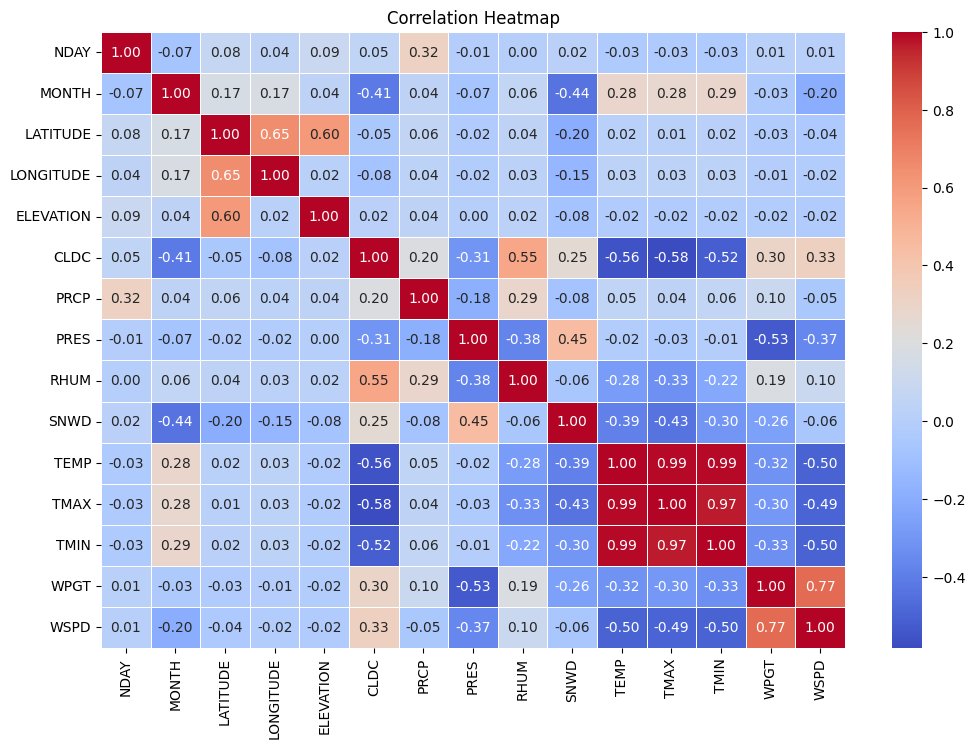

In [3]:
# 1. Calculate the correlation matrix
# (Ensure you only use numeric columns)
DATA_2025 = (DATA_2025 >> mask(X.WPGT.notnull()) >> select('NDAY', X.MONTH, X.LATITUDE, X.LONGITUDE, X.ELEVATION, X.CLDC, X.PRCP, X.PRES, X.RHUM, X.SNWD, X.TEMP, X.TMAX, X.TMIN, X.WPGT, X.WSPD))
corr_matrix = DATA_2025.select_dtypes('number').corr()
# 2. Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Analysis of correlation and step by step regression

Selected features: ['PRCP', 'RHUM', 'TMAX']
Best Score (R2): 0.10544580993486374


c:\Users\Diana\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mlxtend\feature_selection\sequential_feature_selector.py:903: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  std_err = scipy.stats.sem(ary)


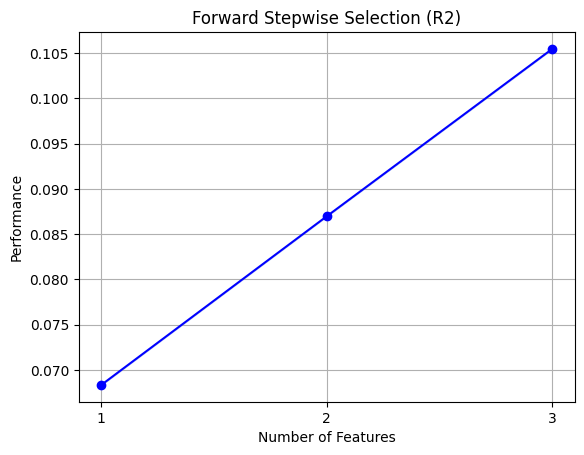

In [4]:
DATA_2025.WPGT = DATA_2025.WPGT.fillna(DATA_2025.WPGT.mean())
DATA_2025 = DATA_2025.dropna()
X = DATA_2025.drop('NDAY', axis = 1)
y = DATA_2025['NDAY']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
lr = LinearRegression()
sfs = SFS(lr,k_features=3,forward=True,floating=False,scoring='r2',cv=0)
sfs = sfs.fit(X_train, y_train)
selected_features = list(sfs.k_feature_names_)
print("Selected features:", selected_features)
print('Best Score (R2):', sfs.k_score_)
fig1 = plot_sfs(sfs.get_metric_dict(), kind='std_dev')
plt.title('Forward Stepwise Selection (R2)')
plt.grid()
plt.show()

Analysis of Importance Features

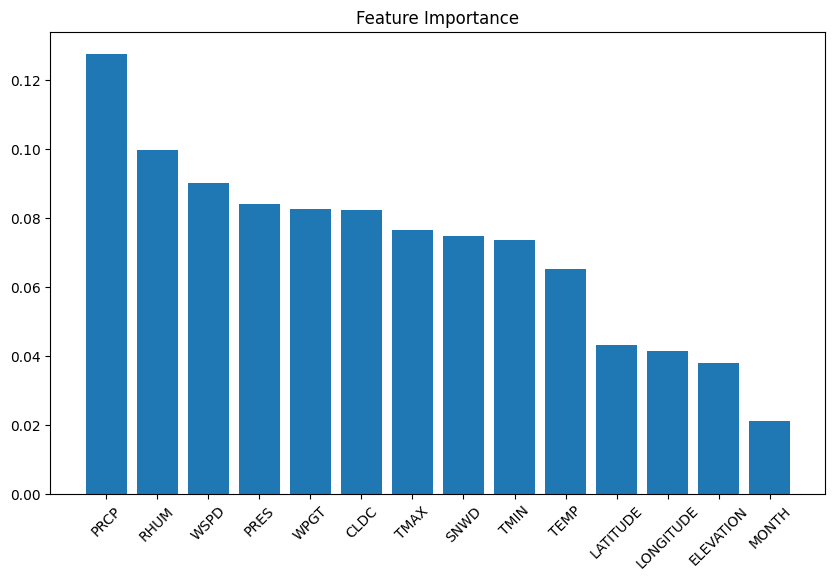

In [5]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
importance_scores = clf.feature_importances_
feature_importance_df = pd.DataFrame({'feature': X.columns.values, 'importance': importance_scores})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(x=feature_importance_df['feature'], height=feature_importance_df['importance'])
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.show()

Bayesian Gaussian Mixture Model

In [ ]:
X_train = DATA_2025[['RHUM', 'CLDC', 'PRES', 'PRCP', 'MONTH']].values
y_train = DATA_2025['NDAY'].values.reshape(-1, 1)
# Combine them for density estimation
data_combined = np.hstack([X_train, y_train])
# Initialize the model
# weight_concentration_prior helps it decide how many 'types' of weather-days exist
bgmr = BayesianGaussianMixture(n_components=4, weight_concentration_prior=0.01, random_state=42)
bgmr.fit(data_combined)

,"n_components n_components: int, default=1The number of mixture components. Depending on the data and the valueof the `weight_concentration_prior` the model can decide to not useall the components by setting some component `weights_` to values veryclose to zero. The number of effective components is therefore smallerthan n_components.",4
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full' (each component has its own general covariance matrix),- 'tied' (all components share the same general covariance matrix),- 'diag' (each component has its own diagonal covariance matrix),- 'spherical' (each component has its own single variance).",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain on the likelihood (of the training data withrespect to the model) is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The result with the highestlower bound value on the likelihood is kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and thecovariances. String must be one of:- 'kmeans': responsibilities are initialized using kmeans.- 'k-means++': use the k-means++ method to initialize.- 'random': responsibilities are initialized randomly.- 'random_from_data': initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weight_concentration_prior_type weight_concentration_prior_type: {'dirichlet_process', 'dirichlet_distribution'}, default='dirichlet_process'String describing the type of the weight concentration prior.",'dirichlet_process'
,"weight_concentration_prior weight_concentration_prior: float or None, default=NoneThe dirichlet concentration of each component on the weightdistribution (Dirichlet). This is commonly called gamma in theliterature. The higher concentration puts more mass inthe center and will lead to more components being active, while a lowerconcentration parameter will lead to more mass at the edge of themixture weights simplex. The value of the parameter must be greaterthan 0. If it is None, it's set to ``1. / n_components``.",0.01
,"mean_precision_prior mean_precision_prior: float or None, default=NoneThe precision prior on the mean distribution (Gaussian).Controls the extent of where means can be placed. Largervalues concentrate the cluster means around `mean_prior`.The value of the parameter must be greater than 0.If it is None, it is set to 1.",None
,"mean_prior mean_prior: array-like, shape (n_features,), default=NoneThe prior on the mean distribution (Gaussian).If it is None, it is set to the mean of X.",None


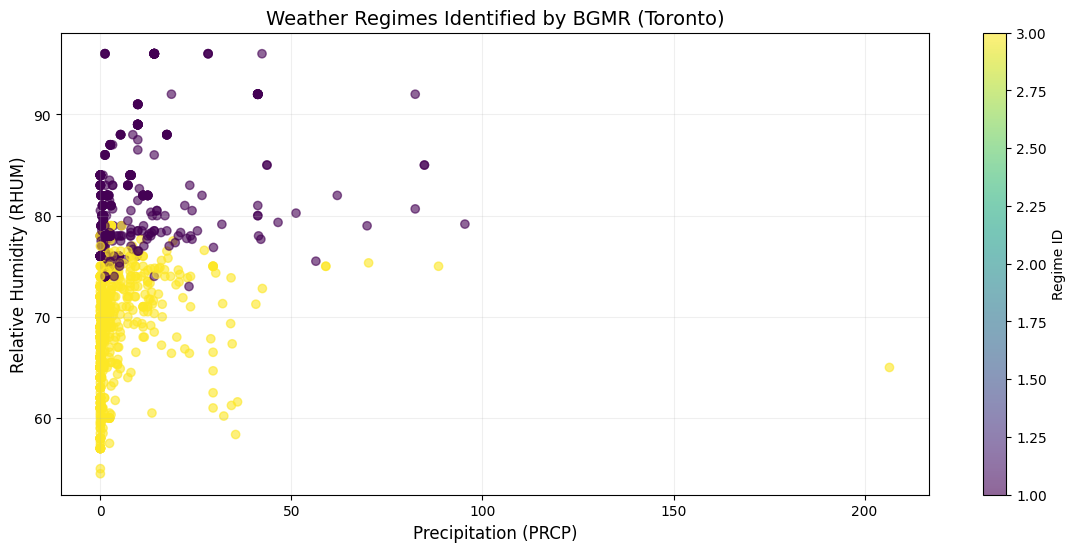

In [26]:
X = DATA_2025[['NDAY', 'RHUM', 'CLDC', 'PRES', 'PRCP', 'MONTH']].dropna().values
pothole_range = np.linspace(0, X[:, -1].max() * 1.5, 1000)
pdf_total = np.zeros_like(pothole_range)
# WEATHER REGIMES (CLUSTERS)
# We plot two of your most correlated variables to see the groups
plt.figure(figsize=(14, 6))
labels = bgmr.predict(X)

# Scatter plot colored by the identified regime
scatter = plt.scatter(X[:, 4], X[:, 1], c=labels, cmap='viridis', alpha=0.6) # PRCP vs RHUM
plt.colorbar(scatter, label='Regime ID')
plt.title('Weather Regimes Identified by BGMR (Toronto)', fontsize=14)
plt.xlabel('Precipitation (PRCP)', fontsize=12)
plt.ylabel('Relative Humidity (RHUM)', fontsize=12)
plt.grid(alpha=0.2)
plt.show()

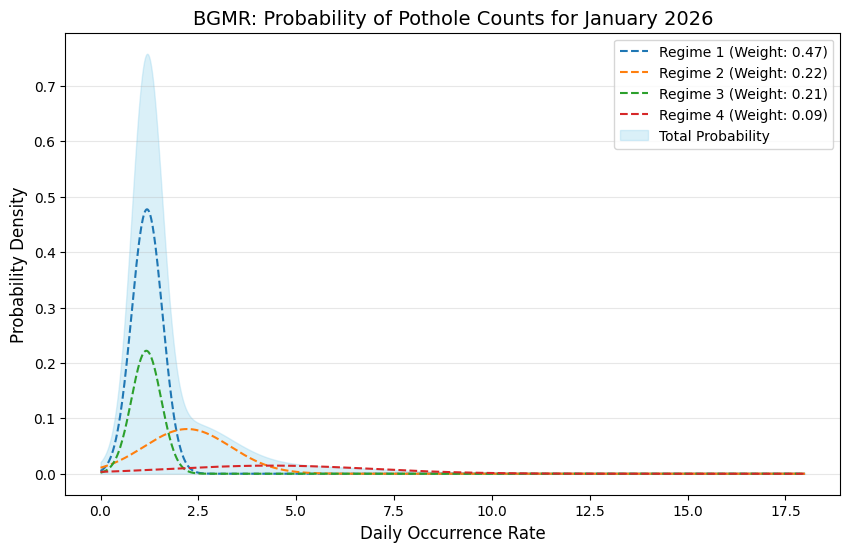

In [28]:
pothole_range = np.linspace(0, X[:, -1].max() * 1.5, 1000)
pdf_total = np.zeros_like(pothole_range)
plt.figure(figsize=(10, 6))
# Define the range for the x-axis (number of potholes)
for i in range(bgmr.n_components):
    weight = bgmr.weights_[i]
    if weight > 0.05:  # Only plot significant clusters
        mean = bgmr.means_[i, -1]  # Mean of pothole_count for this cluster
        var = bgmr.covariances_[i, -1, -1] # Variance of pothole_count
        std = np.sqrt(var)
        # Calculate the PDF for this component
        pdf = weight * norm.pdf(pothole_range, mean, std)
        pdf_total += pdf
        plt.plot(pothole_range, pdf, linestyle='--', label=f'Regime {i+1} (Weight: {weight:.2f})')

plt.fill_between(pothole_range, pdf_total, color='skyblue', alpha=0.3, label='Total Probability')
plt.title('BGMR: Probability of Pothole Counts for January 2026', fontsize=14)
plt.xlabel('Daily Occurrence Rate', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [14]:
X_train = DATA_2025[['RHUM', 'CLDC', 'PRES', 'PRCP', 'MONTH']].values
y_train = DATA_2025['NDAY'].values.reshape(-1, 1)
data_combined = np.hstack([X_train, y_train])
bgmr = BayesianGaussianMixture(n_components=4, weight_concentration_prior=0.01, random_state=42)
bgmr.fit(data_combined)
regime_nday_averages = bgmr.means_[:, -1]
jan_2026_input = DATA_2026[['RHUM', 'CLDC', 'PRES', 'PRCP', 'MONTH']].values
zeros = np.zeros((jan_2026_input.shape[0], 1))
# 2. Add this zero column to your 5 weather features to make it 6 columns
# Now the dimensions match what the model saw during .fit()
jan_2026_fixed = np.hstack([jan_2026_input, zeros])
# 3. Now you can get the probabilities without the error
regime_probs = bgmr.predict_proba(jan_2026_fixed)
# 4. Get the 'Typical NDAY' for each regime (the last column of the means)
# Index 5 is the NDAY average for each of your 4 components
regime_nday_averages = bgmr.means_[:, 5]
# 5. Calculate the numeric prediction
DATA_2026['PREDICTED_NDAY'] = np.dot(regime_probs, regime_nday_averages)

In [ ]:
# Create a Risk Score from 0 to 5 for your dashboard
DATA_2026['RISK_SCORE'] = (DATA_2026['PREDICTED_NDAY'] * 2).clip(0, 5)
conditions = [
    (DATA_2026['RISK_SCORE'] <= 1.0),
    (DATA_2026['RISK_SCORE'] > 1.0) & (DATA_2026['RISK_SCORE'] <= 2.0),
    (DATA_2026['RISK_SCORE'] > 2.0) & (DATA_2026['RISK_SCORE'] <= 3.0),
    (DATA_2026['RISK_SCORE'] > 3.0) & (DATA_2026['RISK_SCORE'] <= 4.5),
    (DATA_2026['RISK_SCORE'] > 4.5)
]
labels = ['Minimal', 'Low', 'Moderate-High', 'Severe', 'Critical']
# 2. Apply the categorization
DATA_2026['RISK_LEVEL'] = np.select(conditions, labels, default='Unknown')
DATA_2026.to_excel('RESULT.xlsx', index=False, sheet_name= 'DATA') 